In [ ]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import os
import re
import cv2
import pickle
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization, Activation, Add, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D, Flatten, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Ruta
path_pokemon = '/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/pokemonDB_dataset.csv'

# Carga de datos
df = pd.read_csv(path_pokemon)

In [ ]:
# Dividir los tipos múltiples en listas
listas_de_tipos = df['Type'].str.split(',')

conteo_tipos = Counter()

for lista in listas_de_tipos:
        # Creamos una lista limpia para cada Pokémon
        tipos_limpios = []
        for tipo in lista:
            # .strip() elimina espacios en blanco al inicio o final
            # ej. " Ice" -> "Ice"
            tipos_limpios.append(tipo.strip())

        # Actualizamos el conteo con los tipos limpios
        conteo_tipos.update(tipos_limpios)

In [ ]:
def normalize_name(name):
    """
    Limpia un nombre de Pokémon para que coincida
    entre el CSV y los nombres de las carpetas.
    """
    if not isinstance(name, str):
        name = str(name)


    # 2. Quitar paréntesis y espacios
    #    (Hacemos esto primero para limpiar formatos)
    name = name.replace("(", "").replace(")", "")

    # 3. Reemplazar caracteres especiales
    name = name.replace('♀', '-f')       # Nidoran♀ -> nidoran-f
    name = name.replace('♂', '-m')       # Nidoran♂ -> nidoran-m
    name = name.replace("'", "")       # Farfetch'd -> farfetchd
    name = name.replace(".", "")       # Mime Jr. -> mimejr
    name = name.replace("_", "-")      # Farfetch_d -> farfetch-d

    return name

    print("Creando mapa de etiquetas normalizado...")

label_map = {}

for index, row in df.iterrows():

    # Obtener el nombre "sucio" del CSV
    nombre_pokemon_csv = row['Pokemon']

    # Manejar los casos especiales de Nidoran

    if "Nidoran♀ (female)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♀"
    elif "Nidoran♂ (male)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♂"
    else:
        # Si no es un caso especial, usar el nombre tal cual
        nombre_a_normalizar = nombre_pokemon_csv

    # 1. Normalizar el nombre (ya sea el original o el pre-limpiado)
    nombre_normalizado = normalize_name(nombre_a_normalizar)

    # 2. Obtener los tipos
    tipos_str = row['Type']
    lista_de_tipos = [tipo.strip() for tipo in tipos_str.split(',')]

    # 3. Guardar en el mapa con la clave normalizada
    if nombre_normalizado not in label_map:
        label_map[nombre_normalizado] = lista_de_tipos
    else:
        pass

print(f"--- Mapa de Etiquetas Creado. {len(label_map)} entradas únicas. ---")

# (Opcional) Verifica que los nombres clave se normalizaron bien
print("\nEjemplo del mapa (normalizado):")
print(f"'nidoran-f': {label_map.get('nidoran-f')}")
print(f"'nidoran-m': {label_map.get('nidoran-m')}")
print(f"'aegislashbladeforme': {label_map.get('aegislashbladeforme')}")
print(f"'farfetchd': {label_map.get('farfetchd')}")
print(f"'mimejr': {label_map.get('mimejr')}")

--- Mapa de Etiquetas Creado. 1215 entradas únicas. ---

Ejemplo del mapa (normalizado):
'nidoran-f': None
'nidoran-m': None
'aegislashbladeforme': None
'farfetchd': None
'mimejr': None


In [ ]:
if not os.path.exists("/content/pokemon1"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Images DB.zip" "/content/pokemon1.zip"
  print("¡Copia finalizada!")
  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon1.zip -d /content/pokemon1
  print("¡Dataset listo en /content/pokemon1!")
else:
  print("El dataset ya está en /content/pokemon1")

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon1!


In [ ]:
if not os.path.exists("/content/pokemon2"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Dataset.zip" "/content/pokemon2.zip"
  print("¡Copia finalizada!")

  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon2.zip -d /content/pokemon2
  print("¡Dataset listo en /content/pokemon2!")
else:
  print("El dataset ya está en /content/pokemon2")

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon2!


In [ ]:
if not os.path.exists("/content/pokemon3"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Fotos Pokemon1.zip" "/content/pokemon3.zip"
  print("¡Copia finalizada!")

  # --- PASO 2: Descomprimir el ZIP en el disco local ---
  # Esto es súper rápido.
  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon3.zip -d /content/pokemon3
  print("¡Dataset listo en /content/pokemon3!")
else:
  print("El dataset ya está en /content/pokemon3")

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon3!


In [ ]:
carpeta_raiz = '/content/pokemon1'
X_rutas_imagenes = []
y_etiquetas = []

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# --- Verificación Rápida ---
if len(X_rutas_imagenes) > 0:
    print("Ejemplo de datos recopilados:")
    print(f"Ruta: {X_rutas_imagenes[0]}")
    print(f"Etiqueta: {y_etiquetas[0]}")
else:
    print("¡Advertencia! No se encontró ninguna imagen. Revisa la 'carpeta_raiz' y los nombres en el CSV.")



carpeta_raiz_nueva = r'/content/pokemon2'

print(f"\nIniciando exploración de la segunda fuente de datos: {carpeta_raiz_nueva}...")
imagenes_encontradas_antes = len(X_rutas_imagenes)

# Usamos os.walk para explorar la nueva ruta
for root, dirs, files in os.walk(carpeta_raiz_nueva):

    # 2. Filtrar: Buscamos carpetas que sean 'normal' y no 'shiny'
    #    Usamos .lower() para encontrar 'normal' o 'Normal'
    if os.path.sep + 'normal' in root.lower() and 'shiny' not in root.lower():

        # 3. Extraer el nombre del Pokémon
        try:
            partes_ruta = root.split(os.path.sep)

            # La carpeta 'normal' es la de [version]
            # La ruta es: ...\[nombrepokemon]\[generacion]\[juego]\[version]
            # Por lo tanto, el nombre está 3 niveles "arriba" de 'normal'

            # Encontramos el índice de la carpeta 'normal' (o 'Normal')
            idx_normal = -1
            for i, parte in enumerate(partes_ruta):
                if parte.lower() == 'normal':
                    idx_normal = i
                    break

            if idx_normal != -1 and idx_normal >= 3:
                # Extraemos el nombre: [idx_normal - 3]
                nombre_pokemon_folder = partes_ruta[idx_normal - 3]

                # 4. Normalizar el nombre (¡usando la misma función!)
                nombre_normalizado = normalize_name(nombre_pokemon_folder)

                # 5. Buscar en el mapa y añadir
                if nombre_normalizado in label_map:
                    for file_name in files:
                        # Nos aseguramos de tomar solo PNGs/JPGs (NO GIFs)
                        if file_name.endswith(('.png', '.jpg', '.jpeg')):
                            ruta_completa = os.path.join(root, file_name)
                            X_rutas_imagenes.append(ruta_completa)
                            y_etiquetas.append(label_map[nombre_normalizado])
                else:
                    # (Nos avisará si este nombre de carpeta no está en el CSV)
                    print(f"Advertencia (Fuente 2): Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada.")

        except Exception as e:
            print(f"Error procesando ruta {root}: {e}")

print("\n" + "-"*60)
print("Exploración de la segunda fuente de datos completada.")
nuevas_imagenes = len(X_rutas_imagenes) - imagenes_encontradas_antes
print(f"Imágenes añadidas desde esta fuente: {nuevas_imagenes}")
print(f"TOTAL de imágenes encontradas (ambas fuentes): {len(X_rutas_imagenes)}")
print(f"TOTAL de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")



carpeta_raiz = '/content/pokemon3'

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# --- Verificación Rápida ---
if len(X_rutas_imagenes) > 0:
    print("Ejemplo de datos recopilados:")
    print(f"Ruta: {X_rutas_imagenes[0]}")
    print(f"Etiqueta: {y_etiquetas[0]}")
else:
    print("¡Advertencia! No se encontró ninguna imagen. Revisa la 'carpeta_raiz' y los nombres en el CSV.")


Iniciando exploración.
Advertencia: Carpeta 'Pokemon Images DB' (normalizado a 'Pokemon Images DB') no encontrada en el CSV.
Advertencia: Carpeta 'Kyurem (White Kyurem)' (normalizado a 'Kyurem White Kyurem') no encontrada en el CSV.
Advertencia: Carpeta 'Greninja (Ash-Greninja)' (normalizado a 'Greninja Ash-Greninja') no encontrada en el CSV.
Advertencia: Carpeta 'Rotom (Wash Rotom)' (normalizado a 'Rotom Wash Rotom') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Dusk Mane Necrozma)' (normalizado a 'Necrozma Dusk Mane Necrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Unbound)' (normalizado a 'Hoopa Hoopa Unbound') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Ultra Necrozma)' (normalizado a 'Necrozma Ultra Necrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Confined)' (normalizado a 'Hoopa Hoopa Confined') no encontrada en el CSV.
Advertencia: Carpeta 'Galarian Farfetch_d' (normalizado a 'Galarian Farfetch-d') no encontrada

In [ ]:
print("Iniciando binarización de las 15,032 etiquetas...")

mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y_etiquetas)

classes = mlb.classes_
num_classes = len(classes)

print("\n--- Binarizador de Etiquetas Creado ---")
print(f"Número total de clases (tipos) únicas: {num_classes}")
print(f"Clases encontradas: {classes}")

Iniciando binarización de las 15,032 etiquetas...

--- Binarizador de Etiquetas Creado ---
Número total de clases (tipos) únicas: 18
Clases encontradas: ['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']


In [ ]:
# --- 2. Guardar el Binarizador ---
with open('mlb_binarizer.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("\nBinarizador guardado como 'mlb_binarizer.pkl'")


Binarizador guardado como 'mlb_binarizer.pkl'


In [ ]:
# --- 3. División de Datos (Train/Validation) ---
print("\nDividiendo los 15,032 items en Train/Validation...")

X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_rutas_imagenes,
    y_binarized,
    test_size=0.2,
    random_state=42
)

print("\n--- Datos Divididos (Nuevos Totales) ---")
print(f"Imágenes de Entrenamiento (X_train_paths): {len(X_train_paths)}")
print(f"Etiquetas de Entrenamiento (y_train):     {len(y_train)}")
print(f"Imágenes de Validación (X_val_paths):   {len(X_val_paths)}")
print(f"Etiquetas de Validación (y_val):       {len(y_val)}")


Dividiendo los 15,032 items en Train/Validation...

--- Datos Divididos (Nuevos Totales) ---
Imágenes de Entrenamiento (X_train_paths): 12025
Etiquetas de Entrenamiento (y_train):     12025
Imágenes de Validación (X_val_paths):   3007
Etiquetas de Validación (y_val):       3007


In [ ]:
IMG_SIZE = 64
NUM_CLASSES = 18
BATCH_SIZE = 16

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Normalizar
    image = image / 255.0

    return image, label

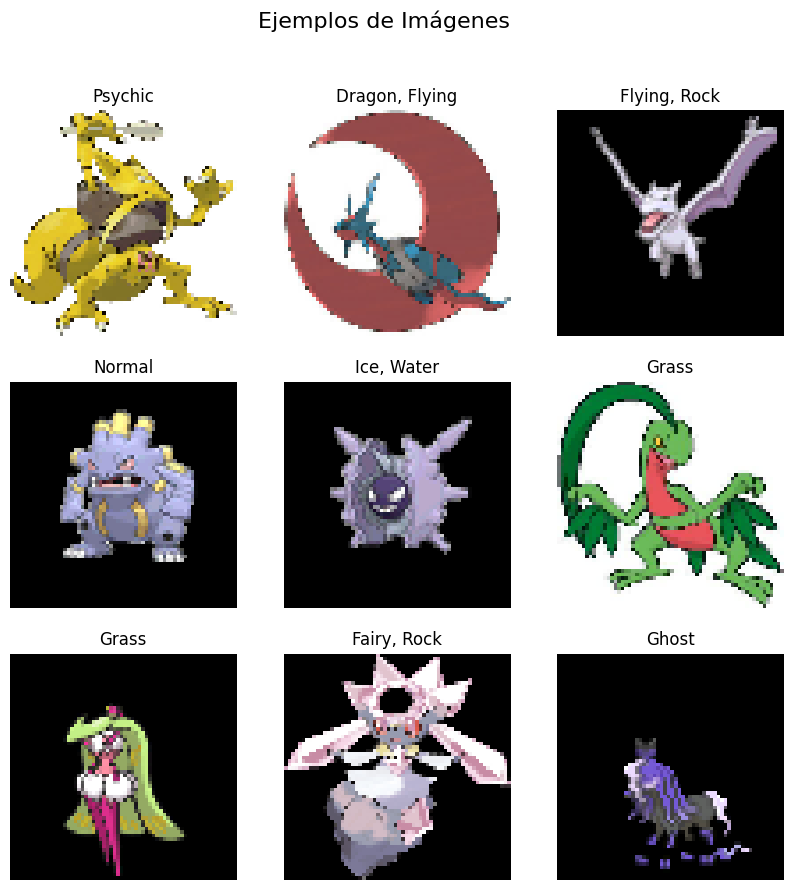

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img_path = X_train_paths[i]
    label = y_train[i]

    image, _ = load_and_preprocess(img_path, label, augment=True)
    plt.imshow(image.numpy())

    tipos_pokemon = [classes[idx] for idx, val in enumerate(label) if val == 1]
    plt.title(", ".join(tipos_pokemon))
    plt.axis("off")
plt.suptitle("Ejemplos de Imágenes", fontsize=16)
plt.show()


In [ ]:
# --- Pipeline de Entrenamiento ---
train_ds = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train))
train_ds = train_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=True),
    num_parallel_calls=AUTOTUNE
)
train_ds = train_ds.shuffle(buffer_size=len(X_train_paths))
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# --- Pipeline de Validación ---
val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val))
val_ds = val_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=False),
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Pipelines de Entrenamiento (train_ds) y Validación (val_ds) creados.")
print(f"   -> train_ds: {train_ds}")
print(f"   -> val_ds:   {val_ds}")

✅ Pipelines de Entrenamiento (train_ds) y Validación (val_ds) creados.
   -> train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.int64, name=None))>
   -> val_ds:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.int64, name=None))>


In [ ]:
def identity_block(X, f, filters, stage, block):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base   = 'bn'  + str(stage) + block + '_branch'
    F1, F2, F3 = filters
    X_shortcut = X

    X = Conv2D(filters=F1, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2a', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F2, kernel_size=(f, f), strides=(1, 1), padding='same', name=conv_name_base + '2b', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F3, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2c', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2c')(X)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def convolutional_block(X, f, filters, stage, block, s=2):
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base   = 'bn'  + str(stage) + block + '_branch'
    F1, F2, F3 = filters
    X_shortcut = X

    # MAIN PATH
    X = Conv2D(filters=F1, kernel_size=(1, 1), strides=(s, s), padding='valid', name=conv_name_base + '2a', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F2, kernel_size=(f, f), strides=(1, 1), padding='same', name=conv_name_base + '2b', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    X = Conv2D(filters=F3, kernel_size=(1, 1), strides=(1, 1), padding='valid', name=conv_name_base + '2c', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name=bn_name_base + '2c')(X)

    # SHORTCUT PATH
    X_shortcut = Conv2D(filters=F3, kernel_size=(1, 1), strides=(s, s), padding='valid', name=conv_name_base + '1', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X_shortcut)
    X_shortcut = BatchNormalization(axis=3, name=bn_name_base + '1')(X_shortcut)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def ResNet50_Adaptada(input_shape, classes):
    X_input = Input(input_shape)
    X = ZeroPadding2D((3, 3))(X_input)

    # Stage 1
    X = Conv2D(64, (7, 7), strides=(2, 2), name='conv1', kernel_initializer=GlorotUniform(seed=0), use_bias=False)(X)
    X = BatchNormalization(axis=3, name='bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block='a', s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

    # Stage 3
    X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

    # Stage 4
    X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

    # Stage 5
    X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

    # HEAD
    X = GlobalAveragePooling2D(name='avg_pool')(X)

    X = Dense(classes, activation='sigmoid', name='fc' + str(classes), kernel_initializer=GlorotUniform(seed=0))(X)

    model = Model(inputs=X_input, outputs=X, name='ResNet50_Adaptada')
    return model

print("✅ Funciones de ResNet (identity_block, convolutional_block, ResNet50_Adaptada) definidas CORREGIDAS.")

✅ Funciones de ResNet (identity_block, convolutional_block, ResNet50_Adaptada) definidas CORREGIDAS.


In [ ]:
model = ResNet50_Adaptada(input_shape=IMG_SHAPE, classes=NUM_CLASSES)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])

print("✅ Modelo ResNet-50 creado y compilado exitosamente para Multi-Etiqueta.")
model.summary()

✅ Modelo ResNet-50 creado y compilado exitosamente para Multi-Etiqueta.


Model: "ResNet50_Adaptada"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 32, 32,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 15, 15,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a      │ (None, 15, 15,    │      4,096 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a       │ (None, 15, 15,    │        256 │ res2a_branch2a[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 15, 15,    │          0 │ bn2a_branch2a[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2b      │ (None, 15, 15,    │     36,864 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2b       │ (None, 15, 15,    │        256 │ res2a_branch2b[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 15, 15,    │          0 │ bn2a_branch2b[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2c      │ (None, 15, 15,    │     16,384 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch1       │ (None, 15, 15,    │     16,384 │ max_pooling2d[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2c       │ (None, 15, 15,    │      1,024 │ res2a_branch2c[0… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch1        │ (None, 15, 15,    │      1,024 │ res2a_branch1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 15,    │          0 │ bn2a_branch2c[0]

 Total params: 23,598,034 (90.02 MB)

 Trainable params: 23,544,914 (89.82 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [30]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

print("✅ Funciones de Transfer Learning listas.")

def create_transfer_model(input_shape, classes):
    """
    Crea un modelo ResNet-50 usando Transfer Learning.
    """

    # --- 1. Cargar la Base Pre-entrenada ---
    # Cargamos ResNet-50 entrenada en ImageNet, sin la capa final
    base_model = ResNet50(
        include_top=False,     # No incluir la capa Dense(1000) de ImageNet
        weights='imagenet',    # Usar los pesos pre-entrenados
        input_shape=input_shape
    )

    # --- 2. Congelar la Base ---
    # Le decimos a Keras que NO re-entrene los 23M de parámetros
    # que acabamos de cargar.
    base_model.trainable = False

    print(f"Base del modelo (ResNet-50) cargada y congelada.")
    print(f"Parámetros de la base (congelados): {base_model.count_params()}")

    # --- 3. Añadir nuestra "Cabeza" (Head) ---
    # Obtenemos la salida de la base y le añadimos nuestras capas
    x = base_model.output

    # El mismo "Head" que ya habíamos definido:
    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dropout(0.5, name='head_dropout')(x) # Regularización

    # ¡LA CAPA FINAL!
    # Usamos 'sigmoid' para nuestro problema multietiqueta
    outputs = Dense(
        num_classes,
        activation='sigmoid',
        name='fc_pokemon'
    )(x)

    # --- 4. Crear y devolver el modelo ---
    model = Model(inputs=base_model.input, outputs=outputs)

    return model

✅ Funciones de Transfer Learning listas.


In [31]:
model = create_transfer_model(input_shape=IMG_SHAPE, classes=NUM_CLASSES)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base del modelo (ResNet-50) cargada y congelada.
Parámetros de la base (congelados): 23587712


In [32]:
# Define un early stopping para evitar el overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,                 # Épocas a esperar sin mejora antes de parar
    mode='min',
    verbose=1,
    restore_best_weights=True    # Restaura los pesos del mejor modelo al final
)

callbacks_list = [early_stopping]

print("✅ Lista de callbacks creada.")

✅ Lista de callbacks creada.


In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_list
)

print("🚀 ¡Entrenamiento completado!")

In [ ]:
# Define un early stopping para evitar el overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,                 # Épocas a esperar sin mejora antes de parar
    mode='min',
    verbose=1,
    restore_best_weights=True    # Restaura los pesos del mejor modelo al final
)

callbacks_list = [early_stopping]

print("✅ Lista de callbacks creada.")

✅ Lista de callbacks creada.


In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_list
)

print("🚀 ¡Entrenamiento completado!")

Epoch 1/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 122s 83ms/step - accuracy: 0.9072 - loss: 0.3624 - precition: 0.1154 - recall: 0.0164 - val_accuracy: 0.9118 - val_loss: 0.4277 - val_precition: 0.1159 - val_recall: 0.0096
Epoch 2/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.9155 - loss: 0.2880 - precition: 0.2288 - recall: 0.0088 - val_accuracy: 0.8956 - val_loss: 57.9745 - val_precition: 0.0833 - val_recall: 0.0258
Epoch 3/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.9152 - loss: 0.2900 - precition: 0.1792 - recall: 0.0058 - val_accuracy: 0.9166 - val_loss: 3.3053 - val_precition: 0.0370 - val_recall: 2.2277e-04
Epoch 4/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - accuracy: 0.9155 - loss: 0.2874 - precition: 0.2360 - recall: 0.0091 - val_accuracy: 0.9158 - val_loss: 0.5645 - val_precition: 0.2839 - val_recall: 0.0098
Epoch 5/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.9153 - loss: 0.2830 - precition: 0.2085 - recall: 0.0084 - val_accuracy: 0.862


Generando cuadrícula de imágenes aleatorias del set de entrenamiento...
Error al cargar /content/pokemon1/Pokemon Images DB/Rhydon/Rhydon.png: not a PNG file
Error al cargar /content/pokemon1/Pokemon Images DB/Espurr/Espurr.png: not a PNG file
Cuadrícula de imágenes guardada como: grid_imagenes_entrenamiento.png


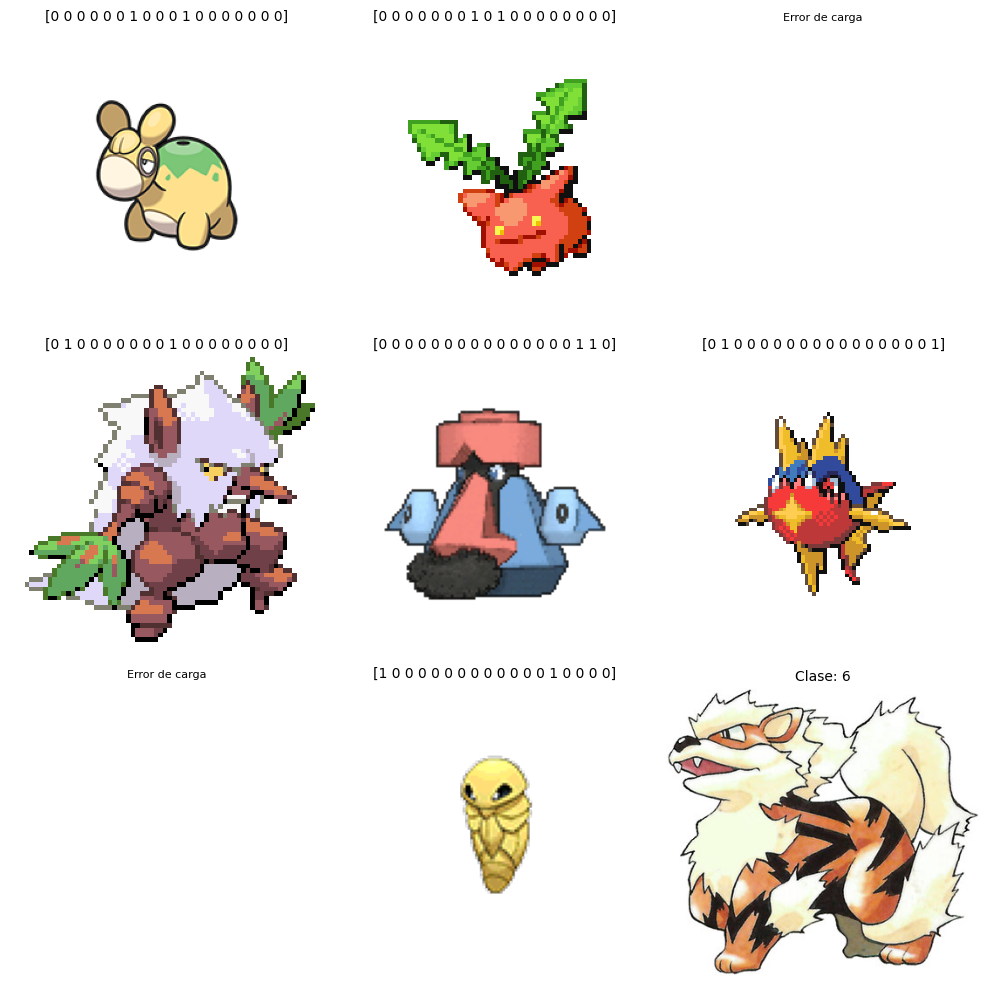

In [ ]:
print("\nGenerando cuadrícula de imágenes aleatorias del set de entrenamiento...")

# Definir el tamaño de la cuadrícula
filas = 3
columnas = 3
num_imagenes = filas * columnas

# Crear la figura y los ejes para la cuadrícula
# figsize ajusta el tamaño total de la imagen
fig, axes = plt.subplots(filas, columnas, figsize=(10, 10))

# Obtener 9 índices aleatorios únicos del conjunto de entrenamiento
# Usamos `random.sample` para asegurar que no haya duplicados
try:
    indices_aleatorios = random.sample(range(len(X_train_paths)), k=num_imagenes)
except ValueError:
    print(f"Error: No tienes suficientes imágenes ({len(X_train_paths)}) para una cuadrícula de {num_imagenes}.")
    # En este caso, simplemente salimos o ajustamos num_imagenes
    indices_aleatorios = [] # Salir

if indices_aleatorios:
    # Aplanar el array de ejes (de 2D a 1D) para iterar fácilmente
    for i, ax in enumerate(axes.flat):
        # Obtener el índice aleatorio
        idx = indices_aleatorios[i]

        # Obtener la ruta de la imagen y la etiqueta
        img_path = X_train_paths[idx]
        label = y_train[idx]

        try:
            # Cargar la imagen desde la ruta
            img = mpimg.imread(img_path)

            # Mostrar la imagen en el eje (subplot)
            ax.imshow(img)

            # --- Formatear el título (etiqueta) ---
            # 'y_train' proviene de 'y_binarized', por lo que puede ser un array one-hot
            # (ej. [0, 1, 0, 0]) o un solo número.
            # Este código intenta manejar ambos casos.
            label_str = ""
            if isinstance(label, (np.ndarray, list)):
                # Si es one-hot, encontramos el índice del '1'
                if np.sum(label) == 1:
                    label_str = f"Clase: {np.argmax(label)}"
                else: # Si es otra cosa (ej. multi-label)
                    label_str = str(label)
            else: # Si es un solo número o string
                label_str = f"Clase: {label}"

            ax.set_title(label_str, fontsize=10)

            # Ocultar los ejes (ticks, labels, etc.)
            ax.axis('off')

        except FileNotFoundError:
            print(f"Error: No se pudo encontrar el archivo {img_path}")
            ax.set_title("Archivo no encontrado", fontsize=8)
            ax.axis('off')
        except Exception as e:
            print(f"Error al cargar {img_path}: {e}")
            ax.set_title("Error de carga", fontsize=8)
            ax.axis('off')

    # Ajustar el espaciado para que los títulos no se superpongan
    plt.tight_layout()

    # Guardar la figura en un archivo
    output_filename = "grid_imagenes_entrenamiento.png"
    plt.savefig(output_filename)
    print(f"Cuadrícula de imágenes guardada como: {output_filename}")

    plt.show()
else:
    print("No hay suficientes imágenes para generar la cuadrícula.")

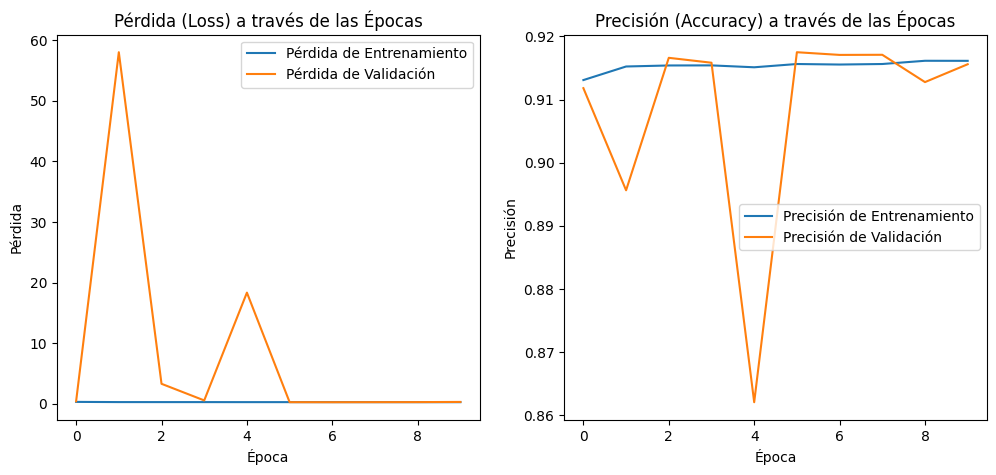

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida (Loss) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

# Graficar Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión (Accuracy) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step


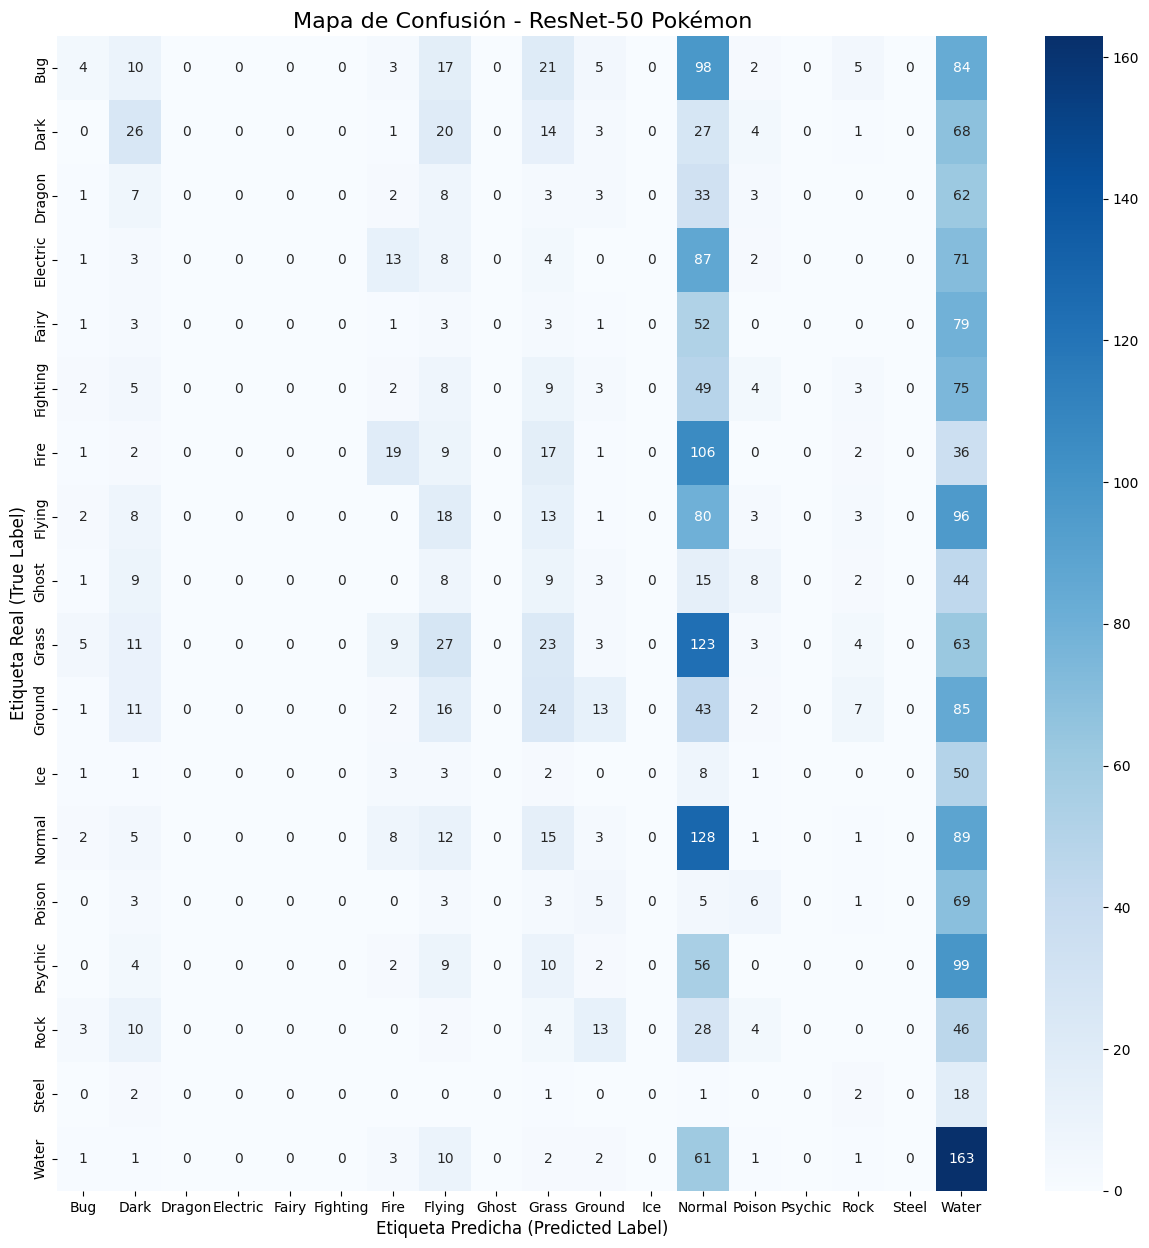

In [ ]:
# Matriz de confusion
plt.figure(figsize=(15, 15))
y_pred_probs = model.predict(val_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)
y_true_indices = np.argmax(np.array(list(y_val)), axis=1)

cm = confusion_matrix(y_true_indices, y_pred_indices)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title('Mapa de Confusión - ResNet-50 Pokémon', fontsize=16)
plt.ylabel('Etiqueta Real (True Label)', fontsize=12)
plt.xlabel('Etiqueta Predicha (Predicted Label)', fontsize=12)

plt.show()


In [ ]:
# --- 1. Generar predicciones (usando el modelo 'sigmoid' entrenado) ---
y_pred_probs = model.predict(val_ds)

# --- 2. Convertir probabilidades a etiquetas ---
# 'sigmoid' nos da probabilidades (0.0 a 1.0) para cada clase.
# Decidimos que cualquier cosa por encima del 50% (0.5) es un "Sí".
y_pred = (y_pred_probs > 0.5).astype(int)

# --- 3. Generar el reporte ---
# 'y_val' son las etiquetas reales, 'y_pred' son las que dijo el modelo
# 'class_names' es tu lista de 18 nombres de Pokémon
print(classification_report(y_val, y_pred, target_names=classes))

188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step
              precision    recall  f1-score   support

         Bug       0.00      0.00      0.00       249
        Dark       0.00      0.00      0.00       164
      Dragon       0.00      0.00      0.00       136
    Electric       0.00      0.00      0.00       200
       Fairy       0.00      0.00      0.00       162
    Fighting       0.00      0.00      0.00       185
        Fire       0.00      0.00      0.00       226
      Flying       0.00      0.00      0.00       345
       Ghost       0.00      0.00      0.00       141
       Grass       0.00      0.00      0.00       355
      Ground       0.00      0.00      0.00       271
         Ice       0.00      0.00      0.00       118
      Normal       0.00      0.00      0.00       409
      Poison       0.00      0.00      0.00       301
     Psychic       0.00      0.00      0.00       315
        Rock       0.00      0.00      0.00       231
       Steel       0.00      0.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
